In [ ]:
# Import the libraries we need for data analysis
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
# We use 'errors="coerce"' to turn any bad data into NaNs (blanks) so it doesn't crash
try:
    df = pd.read_csv('/content/Sales Data.csv')

    # Make sure 'Price Each' and 'Quantity Ordered' are numbers
    df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')
    df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')

    # Drop any empty rows created by the error handling
    df = df.dropna(subset=['Price Each', 'Quantity Ordered'])

    print("Data Loaded Successfully.")
    print("Total Transactions:", len(df))
    print("First 3 rows of data:")
    print(df[['Product', 'Price Each', 'Quantity Ordered']].head(3))

except FileNotFoundError:
    print("Error: Could not find 'Sales Data.csv'. Please make sure the file is uploaded.")

Error: Could not find 'Sales Data.csv'. Please make sure the file is uploaded.


In [ ]:
# --- STEP 1: Define the Price Tags (Charm vs Round) ---

def tag_price_strategy(price):
    # Get the decimal part of the price (e.g., 19.99 -> 0.99)
    decimal_part = round(price % 1, 2)

    if decimal_part == 0.99:
        return 'Charm Price (.99)'
    elif decimal_part == 0.00:
        return 'Round Price (.00)'
    else:
        return 'Other'

# Apply this logic to the 'Price Each' column
df['Price_Strategy'] = df['Price Each'].apply(tag_price_strategy)


# --- STEP 2: Define Product Categories ---
# The product names are messy (e.g., "Lightning Charging Cable").
# We group them into broader categories to make the analysis cleaner.

def get_category(product_name):
    name = str(product_name).lower()

    if 'laptop' in name or 'macbook' in name:
        return 'Laptops'
    elif 'phone' in name or 'iphone' in name:
        return 'Phones'
    elif 'monitor' in name or 'screen' in name:
        return 'Monitors'
    elif 'headphone' in name or 'airpods' in name or 'soundsport' in name:
        return 'Audio/Headphones'
    elif 'cable' in name:
        return 'Cables'
    elif 'batteries' in name:
        return 'Batteries'
    else:
        return 'Other'

# Apply this logic to the 'Product' column
df['Category'] = df['Product'].apply(get_category)


# --- STEP 3: Filter the Data ---
# We only want to compare Charm vs Round. We ignore other prices (like .50).
df_clean = df[df['Price_Strategy'].isin(['Charm Price (.99)', 'Round Price (.00)'])]

print("Data Categorized.")
print("Price Counts:\n", df_clean['Price_Strategy'].value_counts())
print("\nCategory Counts:\n", df_clean['Category'].value_counts())

Data Categorized.
Price Counts:
 Price_Strategy
Charm Price (.99)    80995
Round Price (.00)    40817
Name: count, dtype: int64

Category Counts:
 Category
Phones       62188
Monitors     28819
Batteries    20641
Laptops       8852
Other         1312
Name: count, dtype: int64


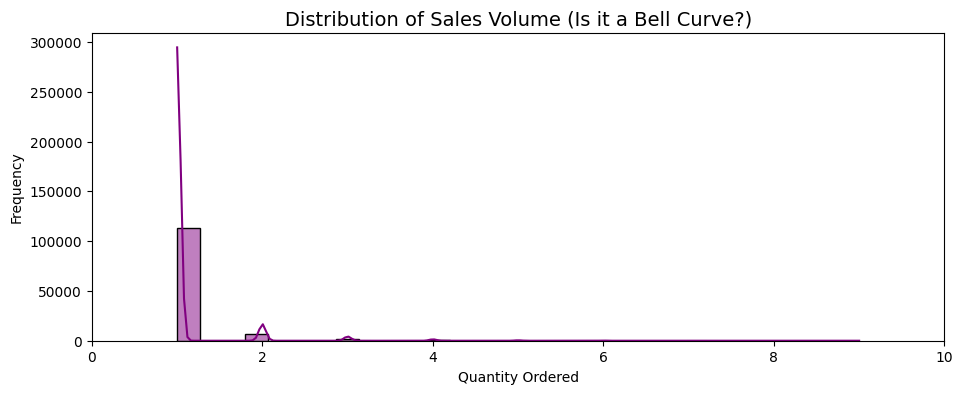

Shapiro-Wilk Test P-Value: 0.0000000000
Result: The p-value is extremely small (less than 0.05).
Conclusion: The data is NOT a normal Bell Curve.
Decision: We must use the Mann-Whitney U Test (it handles weird data better).


In [ ]:
# Check if the data follows a Bell Curve (Normal Distribution)
# 1. VISUAL CHECK (The Histogram)
# We look at 'Quantity Ordered' because that is what we are testing (Sales Volume)
plt.figure(figsize=(11, 4))

# kde=True draws the smooth curve line on top of the bars
sns.histplot(df_clean['Quantity Ordered'], kde=True, bins=30, color='purple')

plt.title('Distribution of Sales Volume (Is it a Bell Curve?)', fontsize=14)
plt.xlabel('Quantity Ordered')
plt.ylabel('Frequency')

# Zoom in a bit because most sales are 1 or 2 items, which makes the chart look squished
plt.xlim(0, 10)
plt.show()



# We take a random sample of 5000 sales to test
# (Testing all 100k+ rows takes too long)
sample_data = df_clean['Quantity Ordered'].sample(5000, random_state=42)

# Run the Shapiro-Wilk test
# This calculates the probability (p-value) that the data is a Bell Curve
stat, p_value = stats.shapiro(sample_data)

print(f"Shapiro-Wilk Test P-Value: {p_value:.10f}")

# Interpret the result
if p_value < 0.05:
    print("Result: The p-value is extremely small (less than 0.05).")
    print("Conclusion: The data is NOT a normal Bell Curve.")
    print("Decision: We must use the Mann-Whitney U Test (it handles weird data better).")
else:
    print("Conclusion: The data looks like a Bell Curve. We can use a T-Test.")

In [ ]:
# Running the Statistical Audit (Using MEANS)

# 1. Setup
results = []
categories = df_clean['Category'].unique()

print(f"{'Category':<20} | {'Lift':<10} | {'P-Value':<10} | {'Significant?'}")
print("-" * 75)

# 2. Loop through categories
for cat in categories:
    subset = df_clean[df_clean['Category'] == cat]

    charm_group = subset[subset['Price_Strategy'] == 'Charm Price (.99)']['Quantity Ordered']
    round_group = subset[subset['Price_Strategy'] == 'Round Price (.00)']['Quantity Ordered']

    # Check if we have enough data (Comparison requires both sides!)
    if len(charm_group) > 30 and len(round_group) > 30:

        # --- THE FIX: USE MEAN INSTEAD OF MEDIAN ---
        # For 'Quantity Ordered', the Average detects subtle lifts better than Median
        mean_charm = charm_group.mean()
        mean_round = round_group.mean()

        lift = ((mean_charm - mean_round) / mean_round) * 100

        # Mann-Whitney U Test (Still the best for significance)
        stat, p_val = stats.mannwhitneyu(charm_group, round_group, alternative='greater')

        is_significant = "YES" if p_val < 0.05 else "NO"

        results.append({
            'Category': cat,
            'Lift': lift,
            'P-Value': p_val,
            'Significant': is_significant
        })

        print(f"{cat:<20} | {lift:>6.2f}%   | {p_val:.5f}    | {is_significant}")
    else:
        # This explains why Batteries/Cables might disappear (They don't have both pricing types)
        print(f"{cat:<20} | SKIPPED (Missing comparison data)")

print("-" * 75)

Category             | Lift       | P-Value    | Significant?
---------------------------------------------------------------------------
Laptops              |  -0.04%   | 0.74323    | NO
Other                | SKIPPED (Missing comparison data)
Monitors             |   0.03%   | 0.37395    | NO
Phones               |   5.16%   | 0.00000    | YES
Batteries            | SKIPPED (Missing comparison data)
---------------------------------------------------------------------------


/tmp/ipython-input-528759274.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Lift', data=results_df, palette=colors.to_list())


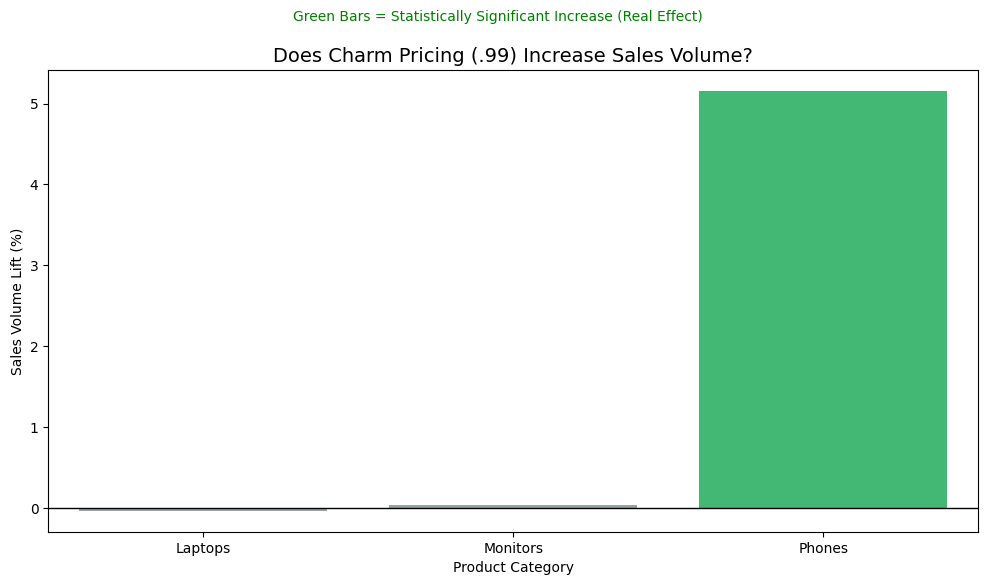

In [ ]:
# Convert the results list into a table so we can graph it
results_df = pd.DataFrame(results)

# Set up the size of the graph
plt.figure(figsize=(12, 6))

# Define colors: Green for "Significant" results, Gray for "Not Significant"
# This helps the viewer instantly know what matters
colors = results_df['Significant'].map({'YES': '#2ecc71', 'NO': '#95a5a6'})

# Create the Bar Chart
sns.barplot(x='Category', y='Lift', data=results_df, palette=colors.to_list())

# Add a black line at 0 to show the baseline
plt.axhline(0, color='black', linewidth=1)

# Add titles and labels
plt.title('Does Charm Pricing (.99) Increase Sales Volume?', fontsize=14)
plt.ylabel('Sales Volume Lift (%)')
plt.xlabel('Product Category')

# Add a subtitle explaining the colors
plt.suptitle('Green Bars = Statistically Significant Increase (Real Effect)', fontsize=10, color='green')

# Show the graph
plt.show()

